# 2 - Training U-Net for Gap-Filling (Generic - Streaming)

**Self-supervised streaming training pipeline** for any Level-3 ocean variable.

This notebook trains a U-Net to fill gaps in satellite ocean observations using **xbatcher streaming** to keep memory bounded. Works for:
- Chlorophyll-a (PACE, Copernicus, CMEMS)
- Sea surface temperature
- Any other gridded ocean variable with cloud/missing data

## Key Features

- **Streaming workflow**: Zarr → xarray/Dask → xbatcher → TensorFlow
- **Memory-bounded**: Never loads full dataset into RAM
- **Spatial chunking**: 40×56 tiles (or configurable)
- **Generic target variable**: Not hardcoded to chlorophyll
- **Self-supervised**: No gap-free truth needed  
- **Synthetic clouds**: Temporally-correlated fake gaps for training/eval

## Workflow

```
Zarr (on-disk)
  ↓ xr.open_zarr with chunks
Lazy xarray/Dask Dataset
  ↓ build_standardized_lazy (no .load())
Lazy standardized channels
  ↓ xbatcher.BatchGenerator
Spatial tiles (time × 40×56)
  ↓ make_tf_gen → tf.data.Dataset
Training batches
  ↓
model.fit()
```

## Setup

In [1]:
# Import the local checkout when running this notebook from the repository.
import sys
from pathlib import Path

for parent in (Path.cwd(), Path.cwd().parent):
    if (parent / "mindthegap").is_dir():
        sys.path.insert(0, str(parent))
        break

# 1 = PACE, 2 = GlobColour, 3 = IO, 4 = deterministic demo
dataset = 4

# Keep remote validation runs small. Set False for full training.
SMOKE_TEST = True
SMOKE_DAYS = 120
SMOKE_SPATIAL_SIZE = 64

In [2]:
# Icechunk is only required by the PACE and GlobColour loaders.
if dataset in (1, 2):
    get_ipython().run_line_magic("pip", "install -q 'icechunk>=2'")

In [3]:
if dataset in (1, 2):
    import icechunk

    icechunk_major = int(icechunk.__version__.split(".", 1)[0])
    if icechunk_major < 2:
        raise RuntimeError("PACE and GlobColour require icechunk >= 2")
    print(f"Icechunk version: {icechunk.__version__}")

In [4]:
# Earthaccess is only required by the authenticated PACE loader.
if dataset == 1:
    get_ipython().run_line_magic("pip", "install -q 'earthaccess>=0.15'")

In [5]:
if dataset == 1:
    import earthaccess
    from packaging.version import Version

    if Version(earthaccess.__version__) < Version("0.15"):
        raise RuntimeError("PACE requires earthaccess >= 0.15")
    print(f"Earthaccess version: {earthaccess.__version__}")

In [6]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Reduce TensorFlow verbosity

import numpy as np
import pandas as pd
import xarray as xr
import tensorflow as tf
import matplotlib.pyplot as plt
import mindthegap as mtg

# TensorFlow automatically uses CPU when no GPU is available.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Compute device: {'GPU' if gpus else 'CPU'}")
print(f"GPUs available: {len(gpus)}")

2026-08-06 23:26:55.323603: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786058815.342576    7544 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786058815.349081    7544 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786058815.363555    7544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786058815.363584    7544 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786058815.363586    7544 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.1
Compute device: GPU
GPUs available: 1


## 1. Load Your Data

Load your xarray Dataset with **time, lat, lon** dimensions.

### Requirements:
- Target variable (e.g., `chlor_a`, `sst`, `analysed_sst`)
- Cloud/missing flag variable (1 = cloud/missing, 0 = valid data)
- Land flag variable (1 = land, 0 = ocean)
- Optional: Additional predictor variables (SST, winds, salinity, etc.)

### Data Source Examples:

In [7]:
dataset_names = {1: "PACE", 2: "GlobColour", 3: "IO", 4: "demo"}
if dataset not in dataset_names:
    raise ValueError(f"Unknown dataset selection: {dataset}")
print(f"Selected dataset: {dataset_names[dataset]}")

Selected dataset: demo


In [8]:
# Example 1: PACE Chlorophyll (AWS us-west-2 required)
if dataset == 1:
    import earthaccess
    import icechunk as ic
    
    def load_pace_chl(lat_slice, lon_slice):
        auth = earthaccess.login()
        creds = auth.get_s3_credentials(daac="OBDAAC")
        
        url = "https://data.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_CHL"
        storage = ic.http_storage(url)
        vc = ic.credentials.containers_credentials({
            "s3://ob-cumulus-prod-public/": ic.credentials.s3_credentials(
                access_key_id=creds["accessKeyId"],
                secret_access_key=creds["secretAccessKey"],
                session_token=creds["sessionToken"]
            )
        })
        
        store = ic.Repository.open(storage, authorize_virtual_chunk_access=vc).readonly_session("main").store
        ds = xr.open_zarr(store, consolidated=False, group="daily/0p1deg/chunks_512", chunks={})
        ds = ds.sel(lat=lat_slice, lon=lon_slice)
        
        # Derive land and cloud flags (PACE doesn't have explicit flags)
        gap = ds['chlor_a'].isnull()
        land = gap.all(dim='time')
        ds['land_flag'] = land.astype('int8')
        ds['cloud_flag'] = (gap & ~land).astype('int8')
        
        return ds
    
    ds = load_pace_chl(lat_slice=slice(31, 5), lon_slice=slice(42, 80))
    target_var = 'chlor_a'
    feature_vars = []
    missing_flag_var = 'cloud_flag'
    land_flag_var = 'land_flag'

In [9]:
# Example 2: Copernicus GlobColour (via icechunk)
# use this example. Needs icechunk > 2
if (dataset == 2):
    import icechunk as ic
    import xarray as xr
    
    def open_globcolour(lat_slice, lon_slice):
        """Open a spatial subset as a Dask-backed xarray Dataset."""
        url = "https://data.source.coop/fish-pace/globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
        storage = ic.http_storage(url)
        repo = ic.Repository.open(storage)
        auth = {
            prefix: ic.credentials.HttpAccess
            for prefix in repo.config.virtual_chunk_containers or []
        }
        store = repo.reopen(
            authorize_virtual_chunk_access=auth
        ).readonly_session("main").store
    
        ds = xr.open_zarr(store, consolidated=False, chunks={})
        ds = ds[["CHL", "flags"]].sel(lat=lat_slice, lon=lon_slice)
        ds["land_flag"] = (ds["flags"] == 1).astype("int8")
        ds["cloud_flag"] = (
            ds["CHL"].isnull() & (ds["land_flag"] == 0)
        ).astype("int8")
        ds = ds.drop_vars("flags")
    
        return ds
    
    ds = open_globcolour(lat_slice=slice(31, 5), lon_slice=slice(42, 80))
    
    target_var = 'CHL'
    feature_vars = []  # e.g., ['sst', 'u_wind', 'v_wind', 'air_temp']
    missing_flag_var = 'cloud_flag'
    land_flag_var = 'land_flag'


In [10]:
# Example 3: IO (Google Cloud Storage)
if (dataset == 3):
    ds = xr.open_dataset(
        "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/IO_rechunked.zarr",
        engine="zarr",
        backend_kwargs={"storage_options": {"token": "anon"}},
        consolidated=True
    )
    ds = ds.sel(lat=slice(31, 5), lon=slice(42, 80))
    
    target_var = 'CHL_cmes-level3'
    feature_vars = []  # e.g., ['sst', 'u_wind', 'v_wind', 'air_temp']
    missing_flag_var = 'CHL_cmes-cloud'
    land_flag_var = 'CHL_cmes-land'


In [11]:
# Example 4: Demo data
if dataset == 4:
    ds = mtg.demo_data(days=120, lat_size=16, lon_size=16, seed=42)
    
    # Specify your variable names
    target_var = "chlor_a"  # Variable to gap-fill
    feature_vars = []  # e.g., ['sst', 'u_wind', 'v_wind', 'air_temp']
    missing_flag_var = "cloud_flag"  # 1 = missing/cloud, 0 = valid
    land_flag_var = "land_flag"  # 1 = land, 0 = ocean


if SMOKE_TEST and dataset != 4:
    ds = ds.isel(
        time=slice(0, min(SMOKE_DAYS, ds.sizes["time"])),
        lat=slice(0, min(SMOKE_SPATIAL_SIZE, ds.sizes["lat"])),
        lon=slice(0, min(SMOKE_SPATIAL_SIZE, ds.sizes["lon"])),
    )
    print(f"Smoke-test subset: {dict(ds.sizes)}")

if dataset == 3:
    # IO flag value 2 is static land; compute the 2D mask from one day.
    land = ds["CHL_cmes-cloud"].isel(time=0) == 2
    ds["CHL_cmes-land"] = land.astype("int8").broadcast_like(
        ds["CHL_cmes-level3"]
    )

## 2. Build Standardized Training data

Use `build_standardized_lazy()` to create standardized predictors **without loading data into memory**.

In [12]:
# Crop to U-Net-compatible dimensions (multiples of 8)
ds = mtg.crop_to_multiple(ds, multiple=8)

print(f"\nAfter cropping to multiple of 8:")
print(f"Dimensions: {dict(ds.sizes)}")


After cropping to multiple of 8:
Dimensions: {'time': 120, 'lat': 16, 'lon': 16}


In [13]:
# Preprocessing options
log_transform = True  # Apply log to target? (True for chlorophyll, False for SST)
n_temporal_lags = 1  # Number of prev/next day channels (1 = prev1, next1)

# Infer tile sizes from the source chunks, capped to control model memory.
def tile_size(dim, upper_limit=64, multiple=8):
    chunks = ds.chunksizes.get(dim, (ds.sizes[dim],))
    available = min(ds.sizes[dim], chunks[0], upper_limit)
    aligned = available - available % multiple
    if aligned < multiple:
        raise ValueError(f"{dim} must contain at least {multiple} cells")
    return aligned

TILE_LAT = tile_size("lat")
TILE_LON = tile_size("lon")
TIME_CHUNK = min(100, max(1, ds.sizes["time"] // 6))

# Keep each model batch near the original 40 x 56 x 16 pixel budget.
pixels_per_tile = TILE_LAT * TILE_LON
if gpus and pixels_per_tile > 16 * 16:
    # This cuDNN build fails on the U-Net's larger convolution workspaces.
    tf.config.set_visible_devices([], "GPU")
    gpus = []
    print("Using CPU for tiles larger than 16 x 16")
cpu_batch_size = max(1, min(16, (40 * 56 * 16) // pixels_per_tile))
# Conservative GPU batches avoid excessive cuDNN workspace allocation.
BATCH_SIZE = 1 if gpus else cpu_batch_size
short_run = ds.sizes["time"] <= 120
EPOCHS = 2 if short_run else 50
PATIENCE = 2 if short_run else 10

# Use a 50/25/25 split for short datasets and 3/1/rest years otherwise.
train_start = str(pd.to_datetime(ds.time.values[0]).date())
if short_run:
    train_days = ds.sizes["time"] // 2
    val_days = ds.sizes["time"] // 4
else:
    train_days = 3 * 365
    val_days = 365
train_end_date = pd.to_datetime(ds.time.values[0]) + pd.DateOffset(days=train_days)
val_end_date = train_end_date + pd.DateOffset(days=val_days)

# =============================================================================

print(f"Dataset dimensions: {dict(ds.sizes)}")
print(f"Target variable: {target_var}")
print(f"Date range: {pd.to_datetime(ds.time.values[0])} to {pd.to_datetime(ds.time.values[-1])}")

Dataset dimensions: {'time': 120, 'lat': 16, 'lon': 16}
Target variable: chlor_a
Date range: 2020-01-01 00:00:00 to 2020-04-29 00:00:00


In [14]:
# Build lazy standardized dataset
print("Building lazy standardized channels...")

# Align output chunks with tile size for efficient xbatcher reads
output_chunks = {"time": TIME_CHUNK, "lat": TILE_LAT, "lon": TILE_LON}

ds_std, stats = mtg.build_standardized_lazy(
    ds,
    target_variable=target_var,
    missing_flag=missing_flag_var,
    land_flag=land_flag_var,
    features=feature_vars,
    train_dates=slice(train_start, str(train_end_date.date())),
    std_vars=feature_vars + [
        "full_target", "masked_target",
        *[f"masked_target_m{i}" for i in range(1, n_temporal_lags + 1)],
        *[f"masked_target_p{i}" for i in range(1, n_temporal_lags + 1)],
    ],
    log_target=log_transform,
    missing_flag_shift=10,
    n_temporal_lags=n_temporal_lags,
    output_chunks=output_chunks,
    add_geo=False  # Set True to add spherical lat/lon features
)

# Extract channel names (all except full_target)
X_vars = [v for v in ds_std.data_vars if v != 'full_target']
num_channels = len(X_vars)

# Get standardization stats
# The target is named 'full_target' in the prepared dataset and stats
y_mean, y_std = stats['full_target'][0], stats['full_target'][1]

print(f"\nChannels created ({num_channels} total):")
for i, ch in enumerate(X_vars, 1):
    print(f"  {i}. {ch}")
print(f"\nTarget standardization: mean={y_mean:.4f}, std={y_std:.4f}")
print(f"\nDataset is LAZY (not in memory): {ds_std.chunks}")

Building lazy standardized channels...



Channels created (9 total):
  1. masked_target
  2. masked_target_m1
  3. masked_target_p1
  4. day_sin
  5. day_cos
  6. synthetic_missing_flag
  7. true_missing_flag
  8. valid_masked_target_flag
  9. land_flag

Target standardization: mean=0.5280, std=0.1894

Dataset is LAZY (not in memory): Frozen({'time': (20, 20, 20, 20, 20, 20), 'lat': (16,), 'lon': (16,)})


## Streaming Configuration for xbatcher

xbatcher will read tiles on-demand during training

In [15]:
# Streaming and training configuration inferred above from the dataset.
print(f"Training period: {train_start} to {train_end_date.date()}")
print(f"Validation period: {train_end_date.date()} to {val_end_date.date()}")
print(f"Tile size: {TILE_LAT}×{TILE_LON}, Time chunks: {TIME_CHUNK} days")

Training period: 2020-01-01 to 2020-03-01
Validation period: 2020-03-01 to 2020-03-31
Tile size: 16×16, Time chunks: 20 days


## 3. Create xbatcher Streaming Pipeline

Use `mtg.make_xbatcher()` to create tile generators, then wrap with `mtg.make_tf_gen()` for TensorFlow.

In [16]:
# Define spatial patch dimensions
patch_dims = {"time": TIME_CHUNK, "lat": TILE_LAT, "lon": TILE_LON}

# Split data into train/val subsets
ds_train = ds_std.sel(time=slice(train_start, str(train_end_date.date())))
ds_val = ds_std.sel(time=slice(str(train_end_date.date()), str(val_end_date.date())))

print(f"\nTrain time range: {ds_train.time.values[0]} to {ds_train.time.values[-1]}")
print(f"Val time range: {ds_val.time.values[0]} to {ds_val.time.values[-1]}")

# Verify chunk alignment (informational only)
print("\nChecking original chunk alignment...")
print(f"  On-disk chunks (lat): {ds_std.chunksizes.get('lat', 'N/A')}")
print(f"  On-disk chunks (lon): {ds_std.chunksizes.get('lon', 'N/A')}")
print(f"  Patch dims (lat): {patch_dims['lat']}")
print(f"  Patch dims (lon): {patch_dims['lon']}")
lat_chunks = ds_std.chunksizes.get('lat', [])
lon_chunks = ds_std.chunksizes.get('lon', [])
aligned = (lat_chunks and lat_chunks[0] == patch_dims['lat'] and 
           lon_chunks and lon_chunks[0] == patch_dims['lon'])
print(f"  Aligned: {aligned}")
print("  (Note: Already loaded into memory, so alignment only affects .load() speed)")

# Create xbatcher generators on IN-MEMORY data
print("\nCreating xbatcher generators on in-memory data...")
train_batcher = mtg.make_xbatcher(ds_train, patch_dims, overlap=None)
val_batcher = mtg.make_xbatcher(ds_val, patch_dims, overlap=None)

print(f"Train tiles: {len(train_batcher)}")
print(f"Val tiles: {len(val_batcher)}")

# Calculate steps per epoch
train_steps = (len(train_batcher) * TIME_CHUNK) // BATCH_SIZE
val_steps = (len(val_batcher) * TIME_CHUNK) // BATCH_SIZE
print(f"\nSteps per epoch:")
print(f"  Train: {train_steps}")
print(f"  Val: {val_steps}")


Train time range: 2020-01-01T00:00:00.000000000 to 2020-03-01T00:00:00.000000000
Val time range: 2020-03-01T00:00:00.000000000 to 2020-03-31T00:00:00.000000000

Checking original chunk alignment...
  On-disk chunks (lat): (16,)
  On-disk chunks (lon): (16,)
  Patch dims (lat): 16
  Patch dims (lon): 16
  Aligned: True
  (Note: Already loaded into memory, so alignment only affects .load() speed)

Creating xbatcher generators on in-memory data...
Train tiles: 3
Val tiles: 1

Steps per epoch:
  Train: 60
  Val: 20


In [17]:
# Wrap xbatcher generators with TensorFlow Dataset
print("Creating TensorFlow datasets...")

output_signature = (
    tf.TensorSpec(shape=(TILE_LAT, TILE_LON, num_channels), dtype=tf.float32),
    tf.TensorSpec(shape=(TILE_LAT, TILE_LON, 1), dtype=tf.float32),
)

# Note: make_tf_gen expects label variable name
# build_standardized_lazy uses 'full_target' as the target variable
train_dataset = tf.data.Dataset.from_generator(
    mtg.make_tf_gen(train_batcher, X_vars, label='full_target'),
    output_signature=output_signature
).shuffle(512).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    mtg.make_tf_gen(val_batcher, X_vars, label='full_target'),
    output_signature=output_signature
).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)

print("✓ TensorFlow datasets ready")
print(f"  Train: shuffle(512) → batch({BATCH_SIZE}) → repeat → prefetch")
print(f"  Val: batch({BATCH_SIZE}) → repeat → prefetch")

Creating TensorFlow datasets...


✓ TensorFlow datasets ready
  Train: shuffle(512) → batch(1) → repeat → prefetch
  Val: batch(1) → repeat → prefetch


## 4. Build U-Net Model

Fully-convolutional U-Net that can accept any spatial size (trains on 40×56, can predict on full domain).

In [18]:
# Build U-Net
model = mtg.UNet((None, None, num_channels))  # Fully-convolutional

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()

print(f"\nModel input shape: (batch, {TILE_LAT}, {TILE_LON}, {num_channels})")
print(f"Model output shape: (batch, {TILE_LAT}, {TILE_LON}, 1)")

Model: "U-net"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape     ┃    Param # ┃ Connected to     ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ input_layer        │ (None, None,     │          0 │ -                │
│ (InputLayer)       │ None, 9)         │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ conv2d (Conv2D)    │ (None, None,     │      5,248 │ input_layer[0][… │
│                    │ None, 64)        │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ conv2d_1 (Conv2D)  │ (None, None,     │     36,928 │ conv2d[0][0]     │
│                    │ None, 64)        │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ max_pooling2d      │ (None, None,     │          0 │ conv2d_1[0][0]   │
│ (MaxPooling2D)     │ None, 64)        │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ batch_normalizati… │ (None, None,     │        256 │ max_pooling2d[0… │
│ (BatchNormalizati… │ None, 64)        │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ conv2d_2 (Conv2D)  │ (None, None,     │     73,856 │ batch_normaliza… │
│                    │ None, 128)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ conv2d_3 (Conv2D)  │ (None, None,     │    147,584 │ conv2d_2[0][0]   │
│                    │ None, 128)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ max_pooling2d_1    │ (None, None,     │          0 │ conv2d_3[0][0]   │
│ (MaxPooling2D)     │ None, 128)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ batch_normalizati… │ (None, None,     │        512 │ max_pooling2d_1… │
│ (BatchNormalizati… │ None, 128)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ conv2d_4 (Conv2D)  │ (None, None,     │    295,168 │ batch_normaliza… │
│                    │ None, 256)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ conv2d_5 (Conv2D)  │ (None, None,     │    590,080 │ conv2d_4[0][0]   │
│                    │ None, 256)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ max_pooling2d_2    │ (None, None,     │          0 │ conv2d_5[0][0]   │
│ (MaxPooling2D)     │ None, 256)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ batch_normalizati… │ (None, None,     │      1,024 │ max_pooling2d_2… │
│ (BatchNormalizati… │ None, 256)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ conv2d_transpose   │ (None, None,     │    295,040 │ batch_normaliza… │
│ (Conv2DTranspose)  │ None, 128)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ concatenate        │ (None, None,     │          0 │ conv2d_transpos… │
│ (Concatenate)      │ None, 256)       │            │ batch_normaliza… │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ conv2d_6 (Conv2D)  │ (None, None,     │    295,040 │ concatenate[0][… │
│                    │ None, 128)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ conv2d_7 (Conv2D)  │ (None, None,     │    147,584 │ conv2d_6[0][0]   │
│                    │ None, 128)       │            │                  │
├────────────────────┼──────────────────┼────────────┼──────────────────┤
│ ba

 Total params: 2,153,217 (8.21 MB)

 Trainable params: 2,151,937 (8.21 MB)

 Non-trainable params: 1,280 (5.00 KB)


Model input shape: (batch, 16, 16, 9)
Model output shape: (batch, 16, 16, 1)


## 5. Train with Streaming Data

Train using xbatcher streaming—data is loaded one tile at a time, keeping memory bounded.

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print(f"Starting training...")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Steps per epoch: train={train_steps}, val={val_steps}")
print(f"  Early stopping patience: {PATIENCE}")
print(f"\n" + "="*60)

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print(f"Best val_loss: {min(history.history['val_loss']):.6f}")
print(f"Final train_loss: {history.history['loss'][-1]:.6f}")

Starting training...
  Epochs: 2
  Batch size: 1
  Steps per epoch: train=60, val=20
  Early stopping patience: 2

Epoch 1/2


 1/60 ━━━━━━━━━━━━━━━━━━━━ 9:51 10s/step - loss: 0.3786 - mae: 0.4729

12/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7236 - mae: 0.6706  

23/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7374 - mae: 0.6809

33/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7234 - mae: 0.6740

...

57/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2803 - mae: 0.3985


Epoch 2: val_loss improved from 0.35034 to 0.29058, saving model to best_model.keras


60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2395 - mae: 0.3710 - val_loss: 0.2906 - val_mae: 0.4151


Restoring model weights from the end of the best epoch: 2.


Best val_loss: 0.290582
Final train_loss: 0.239490


## 5. Evaluate (Self-Supervised)

Almost certainly broken.

Evaluate on held-out **synthetic clouds** only (pixels we intentionally hid).
Compare to **persistence baseline** (yesterday's value).

In [20]:
# Define test period (after training and validation)
test_start = val_end_date + pd.DateOffset(days=2)  # 2-day buffer
test_end = pd.to_datetime(ds.time.values[-1])

print(f"Test period: {test_start.date()} to {test_end.date()}")

# Select test data from original lazy dataset
ds_test = ds_std.sel(time=slice(str(test_start.date()), str(test_end.date())))

# Load test set into memory for prediction
print("Loading test data...")
ds_test_loaded = ds_test.load()

# Stack input channels
X_test = np.stack([ds_test_loaded[ch].values for ch in X_vars], axis=-1).astype('float32')
print(f"Test data shape: {X_test.shape}")

Test period: 2020-04-02 to 2020-04-29
Loading test data...
Test data shape: (28, 16, 16, 9)


In [21]:
# Predict on test set
print("\nPredicting on test set...")
predictions_std = model.predict(X_test, batch_size=1, verbose=1)

# Unstandardize predictions
predictions = predictions_std[..., 0] * y_std + y_mean

# Get ground truth from original data (in log-space if log_transform=True)
truth_data = ds[target_var].sel(time=slice(str(test_start.date()), str(test_end.date()))).values
if log_transform:
    truth = np.log(np.where(truth_data > 0, truth_data, np.nan))
else:
    truth = truth_data

# Get synthetic cloud mask for test period
synth_cloud_test = ds_test_loaded['synthetic_missing_flag'].values

# Compute metrics only at synthetic clouds (held-out observed pixels)
mask_valid = (synth_cloud_test == 1) & np.isfinite(truth) & np.isfinite(predictions)
test_mae = np.mean(np.abs(predictions[mask_valid] - truth[mask_valid]))
test_rmse = np.sqrt(np.mean((predictions[mask_valid] - truth[mask_valid])**2))

print(f"\nTest set pixels evaluated: {mask_valid.sum():,}")
print(f"U-Net MAE:  {test_mae:.4f}")
print(f"U-Net RMSE: {test_rmse:.4f}")


Predicting on test set...


 1/28 ━━━━━━━━━━━━━━━━━━━━ 20s 756ms/step

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step



Test set pixels evaluated: 0
U-Net MAE:  nan
U-Net RMSE: nan


/srv/conda/envs/notebook/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/srv/conda/envs/notebook/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [22]:
# Persistence baseline (yesterday's value)
print("\nComputing persistence baseline...")
if log_transform:
    all_truth = np.log(np.where(ds[target_var].values > 0, ds[target_var].values, np.nan))
else:
    all_truth = ds[target_var].values

# Get test period indices in full dataset
test_time_idx = np.where((ds.time.values >= np.datetime64(test_start)) & 
                         (ds.time.values <= np.datetime64(test_end)))[0]
persistence = all_truth[test_time_idx - 1]  # Previous day's value

mask_persist = (synth_cloud_test == 1) & np.isfinite(truth) & np.isfinite(persistence)
persist_mae = np.mean(np.abs(persistence[mask_persist] - truth[mask_persist]))
persist_rmse = np.sqrt(np.mean((persistence[mask_persist] - truth[mask_persist])**2))

print(f"Persistence baseline:")
print(f"  MAE:  {persist_mae:.4f}")
print(f"  RMSE: {persist_rmse:.4f}")


Computing persistence baseline...
Persistence baseline:
  MAE:  0.0637
  RMSE: 0.0798


In [23]:
# Summary
print("\n" + "="*60)
print("SELF-SUPERVISED TEST RESULTS")
print("="*60)
print(f"Target variable: {target_var}")
print(f"Evaluation metric: {'log-space' if log_transform else 'linear'} MAE/RMSE")
print(f"Evaluated at {mask_valid.sum()} synthetic cloud pixels")
print()
print(f"{'Metric':<15} {'U-Net':>10} {'Persist':>10} {'Improve':>10}")
print("-" * 60)
print(f"{'MAE':<15} {test_mae:>10.4f} {persist_mae:>10.4f} {(persist_mae-test_mae):>10.4f}")
print(f"{'RMSE':<15} {test_rmse:>10.4f} {persist_rmse:>10.4f} {(persist_rmse-test_rmse):>10.4f}")
print(f"{'% Better':<15} {(1-test_mae/persist_mae)*100:>9.1f}% {(1-test_rmse/persist_rmse)*100:>9.1f}%")
print("="*60)

if test_mae < persist_mae:
    print("\n✓ SUCCESS: Model beats persistence baseline!")
else:
    print("\n✗ Model does not beat persistence. Consider:")
    print("  - More training epochs or data")
    print("  - Additional predictor features (SST, winds, etc.)")
    print("  - Different missing_flag_shift value")
    print("  - Spatial patching (if memory-limited)")


SELF-SUPERVISED TEST RESULTS
Target variable: chlor_a
Evaluation metric: log-space MAE/RMSE
Evaluated at 0 synthetic cloud pixels

Metric               U-Net    Persist    Improve
------------------------------------------------------------
MAE                    nan     0.0637        nan
RMSE                   nan     0.0798        nan
% Better              nan%       nan%

✗ Model does not beat persistence. Consider:
  - More training epochs or data
  - Additional predictor features (SST, winds, etc.)
  - Different missing_flag_shift value
  - Spatial patching (if memory-limited)


## 6. Visualize Training History

This part is broken.

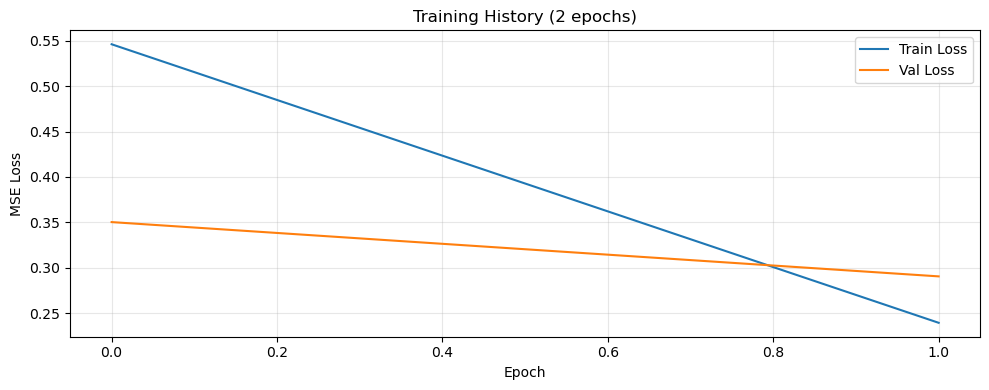


Best epoch: 2
Best val_loss: 0.290582


In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

epochs_run = len(history.history['loss'])
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'Training History ({epochs_run} epochs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

## 7. Test Prediction (Full Domain)

Load one test frame and predict on the full domain to verify the model works.

In [25]:
# Load one test day for full-domain prediction
test_date = str(min(val_end_date + pd.Timedelta(days=15), pd.to_datetime(ds.time.values[-1])).date())
print(f"Test prediction date: {test_date}")

# Select and load test frame
ds_test = ds_std.sel(time=test_date).load()

# Stack channels
X_test = np.stack([ds_test[ch].values for ch in X_vars], axis=-1).astype('float32')
X_test = X_test[np.newaxis, ...]  # Add batch dimension

print(f"Test input shape: {X_test.shape}")

# Predict (fully-convolutional model handles any size)
y_pred = model.predict(X_test, verbose=0)[0, :, :, 0]

# Unstandardize
y_pred_orig = y_pred * y_std + y_mean

print(f"Prediction shape: {y_pred_orig.shape}")
print(f"Prediction range: [{np.nanmin(y_pred_orig):.4f}, {np.nanmax(y_pred_orig):.4f}]")
print("\n✓ Model successfully predicts on full domain")

Test prediction date: 2020-04-15
Test input shape: (1, 16, 16, 9)


Prediction shape: (16, 16)
Prediction range: [nan, nan]

✓ Model successfully predicts on full domain


/tmp/ipykernel_7544/2181993979.py:21: RuntimeWarning: All-NaN slice encountered
  print(f"Prediction range: [{np.nanmin(y_pred_orig):.4f}, {np.nanmax(y_pred_orig):.4f}]")


/tmp/ipykernel_7544/1220469269.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


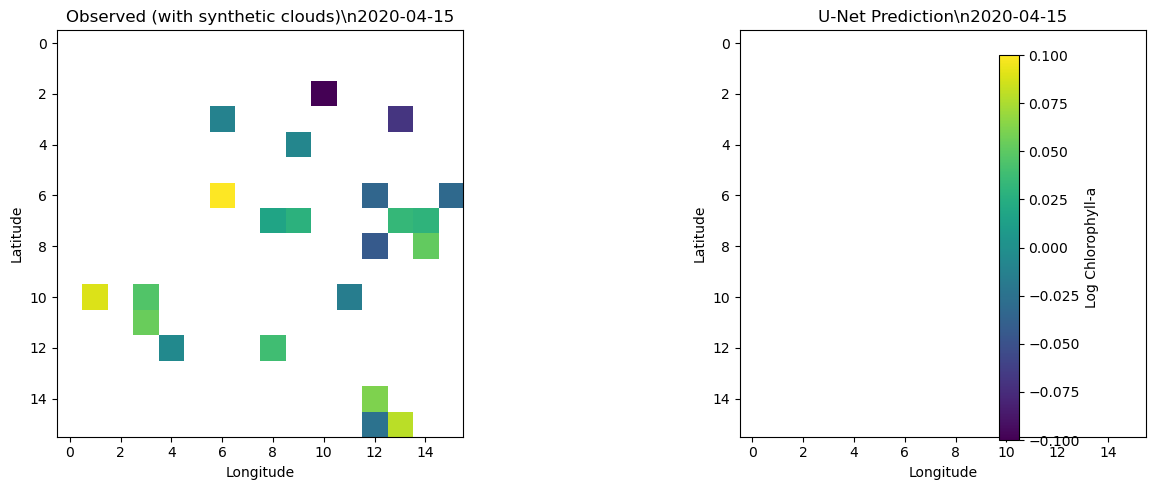

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Observed (with synthetic gaps)
observed = ds_test['masked_target'].values
axes[0].imshow(observed, cmap='viridis', origin='upper')
axes[0].set_title(f'Observed (with synthetic clouds)\\n{test_date}')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Prediction
im = axes[1].imshow(y_pred_orig, cmap='viridis', origin='upper')
axes[1].set_title(f'U-Net Prediction\\n{test_date}')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.colorbar(im, ax=axes, label='Log Chlorophyll-a', fraction=0.02)
plt.tight_layout()
plt.show()

## 8. Save Model

Save the trained model for later use.

In [27]:
model_path = f'unet_generic_streaming_{train_days}day.keras'
model.save(model_path)
print(f"✓ Model saved to: {model_path}")

# Save stats for later unstandardization
import pickle
stats_path = model_path.replace('.keras', '_stats.pkl')
with open(stats_path, 'wb') as f:
    pickle.dump(stats, f)
print(f"✓ Stats saved to: {stats_path}")

✓ Model saved to: unet_generic_streaming_60day.keras
✓ Stats saved to: unet_generic_streaming_60day_stats.pkl
